# Exploratory Data Analysis для NL Day-Ahead Prices

### Цель
Понять структуру данных перед моделированием:
- Распределение целевой переменной и ее особенности
- Временные паттерны (год, сезон, день недели, час)
- Влияние возобновляемых источников энергии (solar/wind) на цены
- Связь с соседними рынками (DE, BE, FR)
- Корреляции с потенциальными фичами

### Данные
`master_hourly_2021_2025.csv` — 5 лет почасовых данных:
- DA цены NL + 3 соседа (DE, BE, FR)
- Газ (TTF), погода, generation forecasts, cross-border flows
- Imbalance prices (long/short)

### Период анализа
2021-01-01 по 2025-12-31

## 1. Setup и загрузка данных

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
import warnings; warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv(
    "../src/data/master_hourly_2021_2025.csv",
    index_col="timestamp", parse_dates=["timestamp"]
)
df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
print(f"Период: {df.index.min().date()} по {df.index.max().date()}")
print(f"Строк: {len(df):,} ({len(df)//24} дней)")
print(f"Колонок: {len(df.columns)}")

Период: 2021-01-01 по 2025-12-31
Строк: 43,820 (1825 дней)
Колонок: 34


## 2. Обзор данных

Что вообще есть в датасете и насколько он "чистый".

In [4]:
print("Группы колонок:\n")
groups = {
    "Prices":     ["nl_day_ahead_price","be_day_ahead_price","de_day_ahead_price","fr_day_ahead_price"],
    "Commodity":  ["gas_price"],
    "Imbalance":  ["imbalance_price_long","imbalance_price_short"],
    "Flows":      [c for c in df.columns if "flow" in c],
    "Weather":    ["temperature_c","wind_ms","solar_radiation","cloud_cover","precipitation","humidity"],
    "Forecasts":  [c for c in df.columns if "forecast" in c],
    "Generation": ["load_mw","solar_mw","wind_mw"],
}
for name, cols in groups.items():
    cols = [c for c in cols if c in df.columns]
    print(f"  {name:<12} ({len(cols)}): {cols}")

print(f"\nNaN per column:")
nan_cols = df.isna().sum()
print(nan_cols[nan_cols > 0].sort_values(ascending=False).to_string())

Группы колонок:

  Prices       (4): ['nl_day_ahead_price', 'be_day_ahead_price', 'de_day_ahead_price', 'fr_day_ahead_price']
  Commodity    (1): ['gas_price']
  Imbalance    (2): ['imbalance_price_long', 'imbalance_price_short']
  Flows        (6): ['flow_nl_to_de', 'flow_de_to_nl', 'net_flow_de_nl', 'flow_nl_to_be', 'flow_be_to_nl', 'net_flow_be_nl']
  Weather      (6): ['temperature_c', 'wind_ms', 'solar_radiation', 'cloud_cover', 'precipitation', 'humidity']
  Forecasts    (12): ['temperature_forecast', 'wind_speed_forecast', 'cloud_cover_forecast', 'precipitation_forecast', 'solar_radiation_forecast', 'pressure_forecast', 'wind_gusts_forecast', 'dew_point_forecast', 'humidity_forecast', 'load_forecast', 'solar_forecast_mw', 'wind_forecast_mw']
  Generation   (3): ['load_mw', 'solar_mw', 'wind_mw']

NaN per column:
solar_forecast_mw        25
wind_forecast_mw         25
gas_price                23
flow_nl_to_be             5
flow_be_to_nl             5
net_flow_be_nl            5
f

## 3. Target: распределение и базовая статистика

Изучаем `nl_day_ahead_price` — это то что мы будем прогнозировать.

Ключевые вопросы:
- Какое распределение?
- Часто ли бывают экстремумы?
- Есть ли сезонные тренды?

In [6]:
tgt = "nl_day_ahead_price"
y = df[tgt]

print(f"Базовая статистика {tgt}")
print(y.describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]).round(2))
print(f"\nSkewness: {y.skew():.2f}  (>0 = right tail)")
print(f"Kurtosis: {y.kurt():.2f}  (>0 = тяжёлые хвосты)")
print(f"\nNeg prices: {(y<0).sum()} ({(y<0).mean()*100:.1f}%)")
print(f"Spikes >300: {(y>300).sum()} ({(y>300).mean()*100:.1f}%)")
print(f"Spikes >500: {(y>500).sum()} ({(y>500).mean()*100:.1f}%)")

Базовая статистика nl_day_ahead_price
count    43820.00
mean       120.95
std         98.85
min       -500.00
1%         -13.13
5%           1.86
10%         35.00
50%         97.00
90%        237.59
95%        321.10
99%        499.88
max        872.96
Name: nl_day_ahead_price, dtype: float64

Skewness: 2.01  (>0 = right tail)
Kurtosis: 6.52  (>0 = тяжёлые хвосты)

Neg prices: 1513 (3.5%)
Spikes >300: 2545 (5.8%)
Spikes >500: 428 (1.0%)


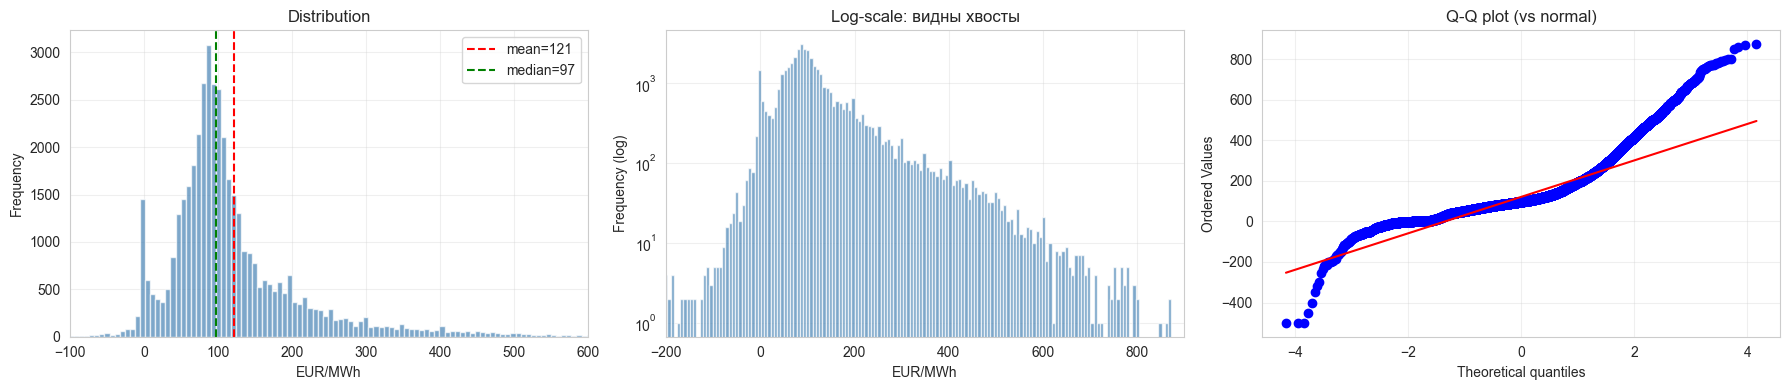

In [8]:
# Распределение цены
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram
axes[0].hist(y, bins=200, color="steelblue", alpha=0.7)
axes[0].axvline(y.mean(), color="red", linestyle="--", label=f"mean={y.mean():.0f}")
axes[0].axvline(y.median(), color="green", linestyle="--", label=f"median={y.median():.0f}")
axes[0].set_xlabel("EUR/MWh"); axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution")
axes[0].legend(); axes[0].set_xlim(-100, 600)

# Log-scale (видны хвосты)
axes[1].hist(y, bins=200, color="steelblue", alpha=0.7)
axes[1].set_yscale("log")
axes[1].set_xlabel("EUR/MWh"); axes[1].set_ylabel("Frequency (log)")
axes[1].set_title("Log-scale: видны хвосты")
axes[1].set_xlim(-200, 900)

# Q-Q plot для нормальности
stats.probplot(y, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot (vs normal)")

plt.tight_layout()
plt.savefig("eda_target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

In [9]:
# Stationarity tests (важно для time series моделей)
print("Stationarity tests\n")
adf_p = adfuller(y.dropna())[1]
print(f"ADF test  p-value: {adf_p:.4f}  ({'STATIONARY' if adf_p < 0.05 else 'NON-stationary'})")

kpss_p = kpss(y.dropna(), regression="c")[1]
print(f"KPSS test p-value: {kpss_p:.4f}  ({'STATIONARY' if kpss_p > 0.05 else 'NON-stationary'})")

# Проверка на тренд по годам (mean by year)
print(f"\nMean DA price by year:")
print(y.groupby(y.index.year).agg(["mean","std","min","max"]).round(1).to_string())

Stationarity tests

ADF test  p-value: 0.0000  (STATIONARY)
KPSS test p-value: 0.0100  (NON-stationary)

Mean DA price by year:
            mean    std    min    max
timestamp                            
2021       103.0   74.7  -66.2  620.0
2022       241.9  131.5 -222.4  871.0
2023        95.8   49.0 -500.0  463.8
2024        77.3   49.5 -200.0  873.0
2025        86.8   49.8 -350.0  523.5


Распределение `nl_day_ahead_price` цены в Нидерландах имеет выраженную асимметрию вправо: среднее значение выше медианы, что указывает на наличие положительных ценовых всплесков. Большая часть наблюдений находится в диапазоне примерно 50–150 EUR/MWh, однако в данных присутствуют как отрицательные цены, так и экстремально высокие значения.

Логарифмическая шкала показывает тяжёлые хвосты распределения: экстремальные значения встречаются редко, но не являются единичными выбросами.

Базовая статистика также показывает сильную нестабильность рынка: в 2022 году средняя цена была существенно выше, чем в остальные годы, что отражает структурный сдвиг в ценовом режиме. После 2022 года средний уровень цены снизился, но экстремальные значения сохраняются.

Отдельно важно, что отрицательные цены составляют около 3.5% наблюдений, а цены выше 300 EUR/MWh — около 5.8%. Это означает, что модель должна уметь работать не только с обычным уровнем цен, но и с редкими экстремальными событиями. Потому что рынок электроэнергии, конечно, решил быть не временным рядом, а эмоциональными качелями в табличном формате.

## 4. Временные паттерны

Рынок электроэнергии характеризуется выраженной временной структурой и сезонностью на нескольких уровнях:

- годовая динамика: изменение рыночных режимов, энергетический кризис, изменение цен на газ
- сезонность по месяцам и временам года: влияние отопительного сезона, температуры и потребления
- различия между рабочими днями и выходными
- внутрисуточные паттерны спроса: утренний рост нагрузки и вечерние peak-hours

Такие временные зависимости являются одной из ключевых особенностей electricity price forecasting.

Следовательно, модель должна уметь учитывать:
- сезонность
- календарные эффекты
- цикличность спроса
- изменение рыночных режимов во времени

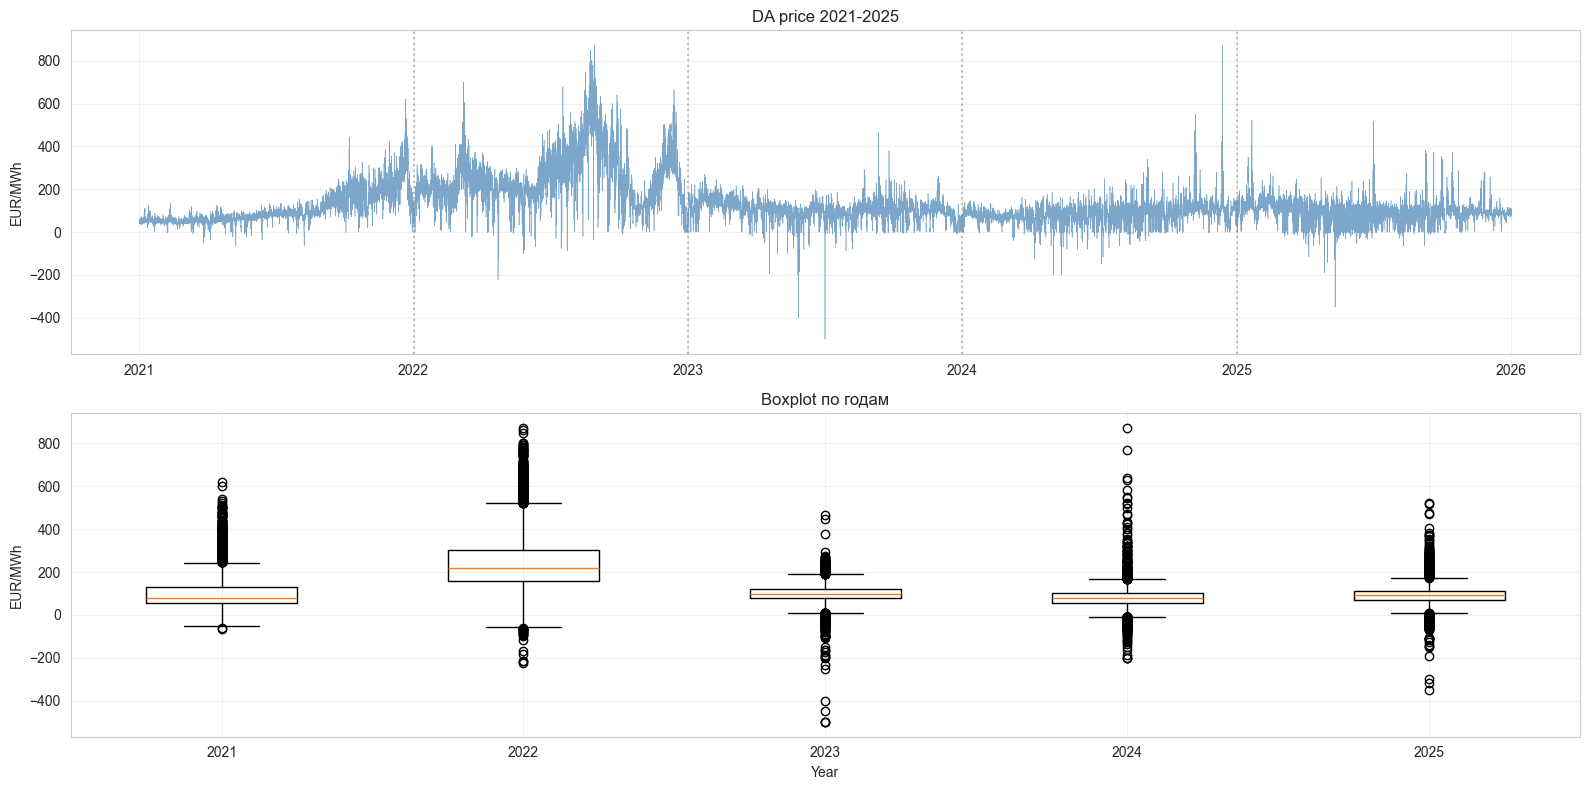

In [10]:
# Цена по годам
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Time series
axes[0].plot(y.index, y.values, color="steelblue", linewidth=0.4, alpha=0.7)
for year in [2022, 2023, 2024, 2025]:
    axes[0].axvline(pd.Timestamp(f"{year}-01-01"), color="gray", linestyle=":", alpha=0.5)
axes[0].set_ylabel("EUR/MWh")
axes[0].set_title("DA price 2021-2025")

# Boxplot by year
years_data = [y[y.index.year == yr].values for yr in range(2021, 2026)]
axes[1].boxplot(years_data, labels=[str(y) for y in range(2021, 2026)], showfliers=True)
axes[1].set_ylabel("EUR/MWh"); axes[1].set_xlabel("Year")
axes[1].set_title("Boxplot по годам")

plt.tight_layout()
plt.savefig("eda_yearly.png", dpi=120, bbox_inches="tight")
plt.show()

На временном ряду хорошо видны структурные изменения рыночного режима в разные годы.

Наиболее нестабильным периодом является 2022 год: наблюдаются резкие ценовые всплески, высокий уровень волатильности и значительное увеличение среднего уровня цены. Это соответствует периоду энергетического кризиса в Европе и росту цен на газ.

После 2022 года рынок частично стабилизируется:

* средний уровень цен снижается
* уменьшается дисперсия
* однако экстремальные значения и резкие spikes по-прежнему присутствуют

Boxplot по годам дополнительно показывает:

* сильное различие распределений между годами
* большое количество выбросов
* наличие отрицательных цен практически во всех периодах
* сохранение тяжёлых хвостов распределения даже после стабилизации рынка

Полученные результаты подтверждают, что рынок электроэнергии является нестационарной системой с изменяющимися рыночными режимами. Это особенно важно учитывать при построении моделей, поскольку поведение модели может существенно меняться между периодами высокой и низкой волатильности.

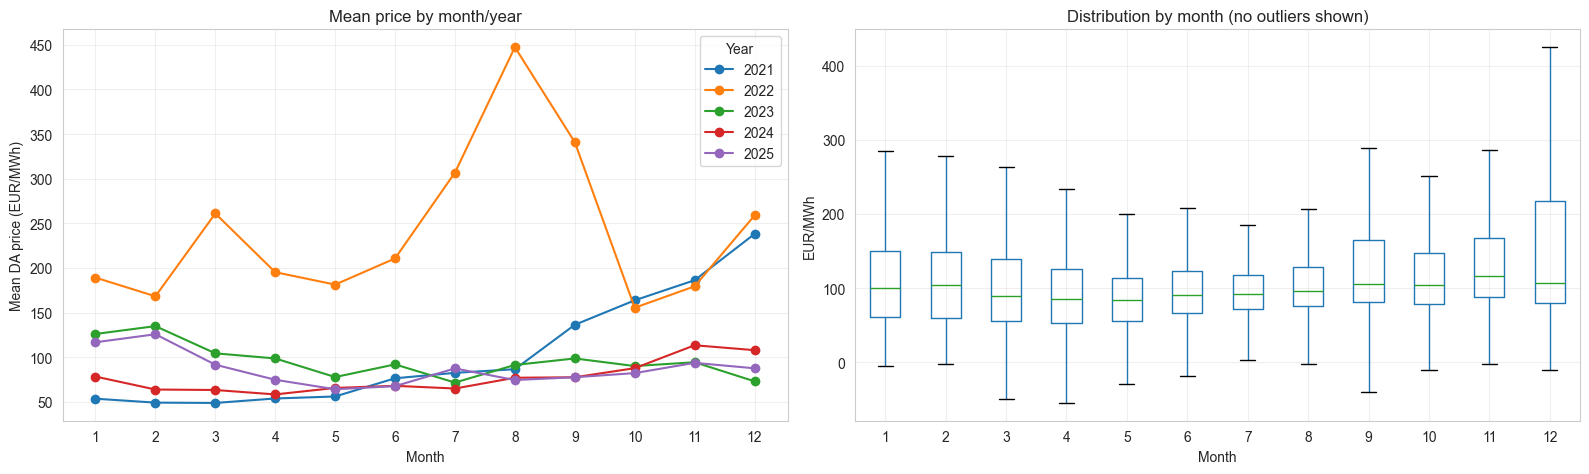

In [11]:
# Месячные паттерны (сезонность)
df_eda = df[[tgt]].copy()
df_eda["year"]  = df_eda.index.year
df_eda["month"] = df_eda.index.month
df_eda["dow"]   = df_eda.index.dayofweek
df_eda["hour"]  = df_eda.index.hour

monthly_pivot = df_eda.pivot_table(values=tgt, index="month", columns="year", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
monthly_pivot.plot(ax=axes[0], marker="o")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Mean DA price (EUR/MWh)")
axes[0].set_title("Mean price by month/year")
axes[0].set_xticks(range(1,13))
axes[0].legend(title="Year")

# Boxplot by month
df_eda.boxplot(column=tgt, by="month", ax=axes[1], showfliers=False)
axes[1].set_xlabel("Month"); axes[1].set_ylabel("EUR/MWh")
axes[1].set_title("Distribution by month (no outliers shown)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("eda_monthly.png", dpi=120, bbox_inches="tight")
plt.show()

На графиках заметна выраженная месячная сезонность цен на электроэнергию.

Средний уровень day-ahead цены существенно меняется в зависимости от времени года:

* зимой цены в среднем выше
* весной и летом наблюдается снижение
* к концу года цены снова начинают расти

Особенно сильные отклонения видны в 2022 году, когда на фоне энергетического кризиса цены резко выросли практически во все месяцы, а пик пришёлся на август.

Boxplot по месяцам показывает, что:

* распределение цен различается между сезонами
* в зимние месяцы увеличивается как медиана цены, так и разброс значений
* осенью и зимой чаще наблюдаются экстремальные значения
* даже без отображения выбросов дисперсия между месяцами остаётся неоднородной

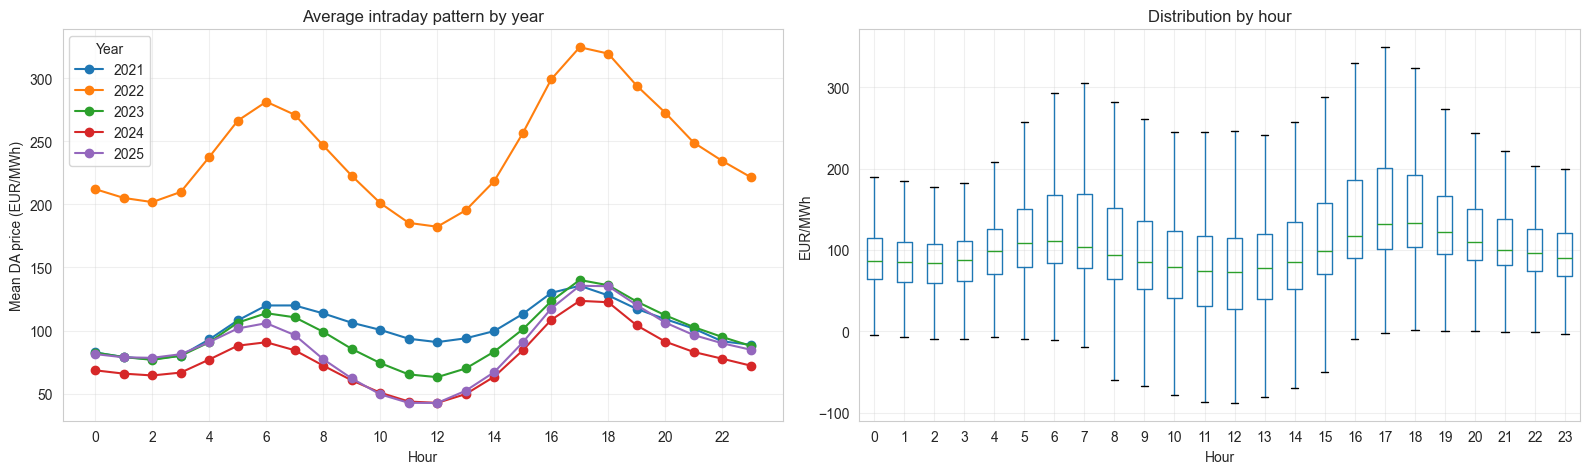

In [ ]:
# Внутридневная динамика (по часам)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean price by hour для каждого года
hourly_pivot = df_eda.pivot_table(values=tgt, index="hour", columns="year", aggfunc="mean")
hourly_pivot.plot(ax=axes[0], marker="o")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Mean DA price (EUR/MWh)")
axes[0].set_title("Average intraday pattern by year")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(title="Year")

# Boxplot by hour
df_eda.boxplot(column=tgt, by="hour", ax=axes[1], showfliers=False)
axes[1].set_xlabel("Hour"); axes[1].set_ylabel("EUR/MWh")
axes[1].set_title("Distribution by hour")
plt.suptitle("")

plt.tight_layout()
plt.savefig("eda_hourly.png", dpi=120, bbox_inches="tight")
plt.show()

На графиках хорошо прослеживается выраженная внутрисуточная сезонность цен на электроэнергию.

Практически во все годы наблюдаются два характерных периода повышенного спроса:

* утренний рост цен в начале рабочего дня
* вечерний пик в часы максимального потребления электроэнергии

Минимальные значения цены чаще всего приходятся на ночные и дневные часы, когда нагрузка на энергосистему ниже, а вклад солнечной генерации выше.

Особенно сильная волатильность наблюдается в вечерние часы, поскольку:

* увеличивается разброс значений
* расширяется межквартильный диапазон
* чаще возникают экстремальные пики

Наиболее нестандартная структура снова наблюдается в 2022 году: общий уровень цен существенно выше, однако форма внутрисуточного паттерна остаётся схожей с другими периодами. Это говорит о том, что даже во время рыночного кризиса базовая структура потребления электроэнергии сохраняется.

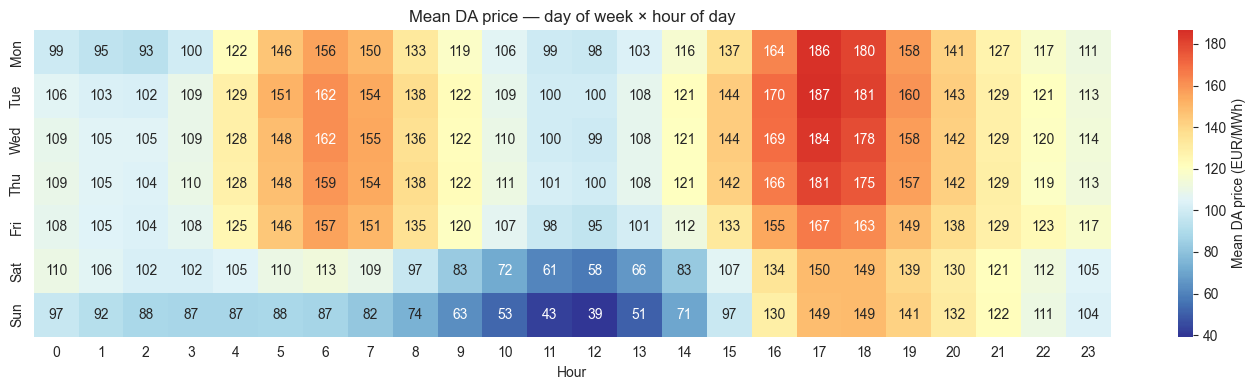

In [12]:
# Heatmap day-of-week × hour-of-day
heatmap_data = df_eda.pivot_table(values=tgt, index="dow", columns="hour", aggfunc="mean")
heatmap_data.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="RdYlBu_r",
            center=heatmap_data.values.mean(), ax=ax,
            cbar_kws={"label":"Mean DA price (EUR/MWh)"})
ax.set_xlabel("Hour"); ax.set_ylabel("")
ax.set_title("Mean DA price — day of week × hour of day")
plt.tight_layout()
plt.savefig("eda_dow_hour_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

Heatmap показывает, что цена электроэнергии зависит не только от часа суток, но и от дня недели.
Наиболее высокие цены наблюдаются:

* в будние дни
* в вечерние часы (примерно 16:00–19:00)
* особенно во вторник–четверг

В эти периоды средняя цена может превышать 180 EUR/MWh, что соответствует часам максимальной нагрузки на энергосистему.

Выходные дни имеют существенно другую структуру:

* общий уровень цен ниже
* внутрисуточные пики выражены слабее
* в воскресенье днём наблюдаются минимальные значения цены

Полученные результаты подтверждают необходимость использования календарных признаков (`hour`, `day_of_week`, `is_weekend`) при построении моделей.

In [ ]:
print("\nINSIGHTS:")
print(f"Самый дорогой час: {heatmap_data.values.max():.1f} EUR/MWh")
print(f"Самый дешёвый час: {heatmap_data.values.min():.1f} EUR/MWh")
print(f"Spread peak/off-peak: {heatmap_data.values.max() - heatmap_data.values.min():.1f}")


INSIGHTS:
Самый дорогой час: 186.5 EUR/MWh
Самый дешёвый час: 39.2 EUR/MWh
Spread peak/off-peak: 147.3


## 5. Анализ спайков (экстремальные цены)

**Спайки - это главная сложность для модели.**

Неободимо проверить следующее:
- Когда происходят high spikes (>p90, >p99)
- Когда происходят low spikes / negative prices
- Связаны ли они с конкретными часами/днями/сезонами?

In [13]:
# Определяем пороги
p90 = y.quantile(0.90); p99 = y.quantile(0.99)
p10 = y.quantile(0.10); p01 = y.quantile(0.01)

print(f"Thresholds — p99: {p99:.1f}  p90: {p90:.1f}  p10: {p10:.1f}  p01: {p01:.1f}")
print(f"\nКоличество событий:")
print(f"  >p99 (extreme high):  {(y>p99).sum()} часов ({(y>p99).mean()*100:.1f}%)")
print(f"  >p90 (high spike):    {(y>p90).sum()} часов ({(y>p90).mean()*100:.1f}%)")
print(f"  <p10 (low spike):     {(y<p10).sum()} часов ({(y<p10).mean()*100:.1f}%)")
print(f"  <p01 (extreme low):   {(y<p01).sum()} часов ({(y<p01).mean()*100:.1f}%)")
print(f"  Negative (<0):        {(y<0).sum()} часов ({(y<0).mean()*100:.1f}%)")

Thresholds — p99: 499.9  p90: 237.6  p10: 35.0  p01: -13.1

Количество событий:
  >p99 (extreme high):  439 часов (1.0%)
  >p90 (high spike):    4382 часов (10.0%)
  <p10 (low spike):     4375 часов (10.0%)
  <p01 (extreme low):   439 часов (1.0%)
  Negative (<0):        1513 часов (3.5%)


По количеству событий видно, что экстремальные значения не являются единичными выбросами. Высокие спайки выше p90 составляют около 10% наблюдений, а цены ниже p10 также встречаются примерно в 10% часов. Отрицательные цены наблюдаются в 3.5% случаев.

Это означает, что модель должна не только прогнозировать средний уровень цены, но и быть устойчивой к редким экстремальным режимам рынка. Иначе она будет бодро предсказывать “средненько”, пока рынок устраивает очередной фейерверк за 500 EUR/MWh.

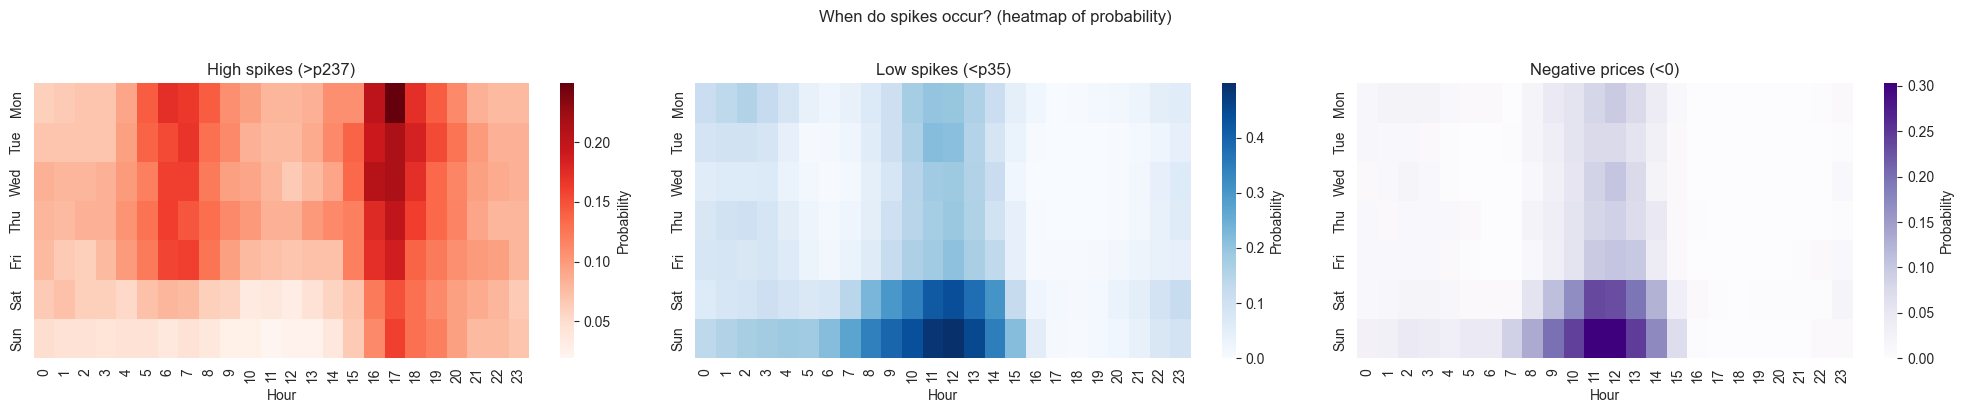

In [14]:
# Когда происходят спайки — heatmap
df_sp = df_eda.copy()
df_sp["is_high_p90"] = (y > p90).astype(int)
df_sp["is_low_p10"]  = (y < p10).astype(int)
df_sp["is_neg"]      = (y < 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

for ax, col, title, cmap in [
    (axes[0], "is_high_p90", f"High spikes (>p{int(p90):.0f})", "Reds"),
    (axes[1], "is_low_p10",  f"Low spikes (<p{int(p10):.0f})",  "Blues"),
    (axes[2], "is_neg",      "Negative prices (<0)",            "Purples"),
]:
    pivot = df_sp.pivot_table(values=col, index="dow", columns="hour", aggfunc="mean")
    pivot.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=False, cbar_kws={"label":"Probability"})
    ax.set_title(title); ax.set_xlabel("Hour"); ax.set_ylabel("")

plt.suptitle("When do spikes occur? (heatmap of probability)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("eda_spike_when.png", dpi=120, bbox_inches="tight")
plt.show()

Heatmap показывает, что экстремальные цены возникают не случайно, а имеют выраженную временную структуру.

High spikes чаще всего происходят в будние дни:

* утром, примерно в 6:00–8:00
* вечером, примерно в 16:00–18:00

Это совпадает с периодами максимального спроса на электроэнергию.

Low spikes и низкие цены чаще всего наблюдаются:

* в дневные часы
* особенно в выходные дни
* наиболее выраженно в субботу и воскресенье около 10:00–13:00

Итого: спайки зависят от комбинации `hour`, `day_of_week` и `is_weekend`, поэтому эти признаки обязательно нужно включать в модель.

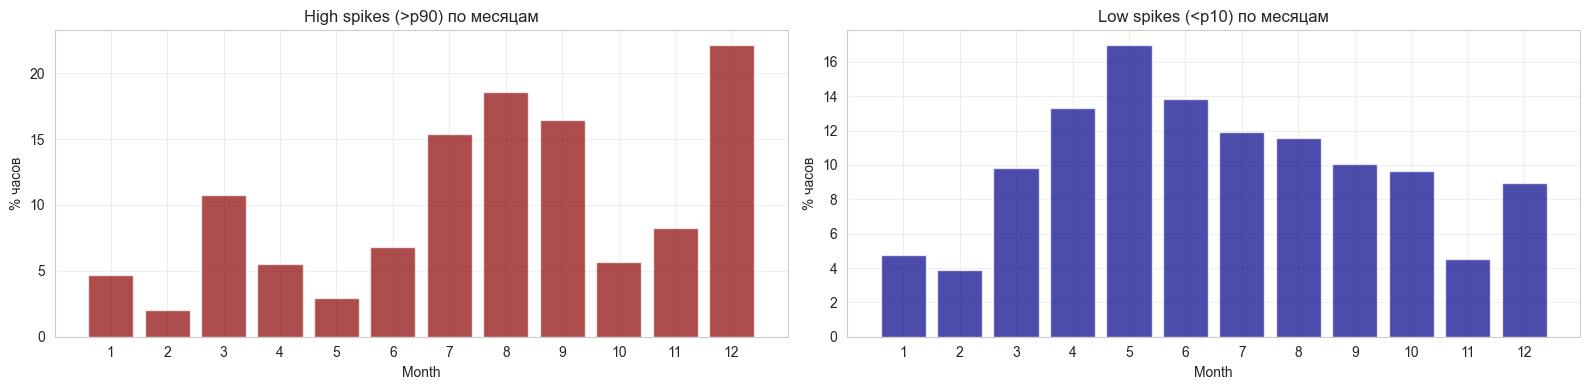


INSIGHTS:
Месяц с max % high spikes: 12-й (22.1%)
Месяц с max % low spikes:  5-й (17.0%)


In [15]:
# Спайки по месяцам
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

monthly_high = df_sp.groupby("month")["is_high_p90"].mean() * 100
monthly_low  = df_sp.groupby("month")["is_low_p10"].mean() * 100

axes[0].bar(monthly_high.index, monthly_high.values, color="darkred", alpha=0.7)
axes[0].set_xlabel("Month"); axes[0].set_ylabel("% часов")
axes[0].set_title(f"High spikes (>p90) по месяцам")
axes[0].set_xticks(range(1, 13))

axes[1].bar(monthly_low.index, monthly_low.values, color="darkblue", alpha=0.7)
axes[1].set_xlabel("Month"); axes[1].set_ylabel("% часов")
axes[1].set_title(f"Low spikes (<p10) по месяцам")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig("eda_spikes_by_month.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nINSIGHTS:")
print(f"Месяц с max % high spikes: {monthly_high.idxmax()}-й ({monthly_high.max():.1f}%)")
print(f"Месяц с max % low spikes:  {monthly_low.idxmax()}-й ({monthly_low.max():.1f}%)")

Частота экстремальных цен также существенно зависит от времени года.

* High spikes (>p90) наиболее часто возникают во второй половине года (особенно в июле–сентябре), при этом максимальная доля наблюдается в декабре.

Это может быть связано с сочетанием высокого спроса, волатильности рынка газа и периодов ограниченного предложения электроэнергии.

* Low spikes (<p10), наоборот, чаще встречаются весной и летом (собенно в апреле–июне).

В этот период увеличивается вклад возобновляемых источников, прежде всего солнечной генерации, что может приводить к снижению рыночной цены.

## 6. Влияние возобновляемой генерации (solar/wind)

В энергосистеме Нидерландов высокая доля возобновляемых источников энергии, прежде всего солнечной и ветровой генерации.

Ожидается следующая зависимость между возобновляемой генерацией и ценами электроэнергии:

- высокая ветровая генерация способствует снижению цен
- высокая солнечная генерация снижает цены в дневные часы и может приводить к отрицательным ценам
- низкая генерация ВИЭ увеличивает вероятность роста цен, особенно в peak-hours

Это связано с тем, что возобновляемая генерация имеет низкую марж стоимость и напрямую влияет на баланс спроса и предложения на рынке электроэнергии.

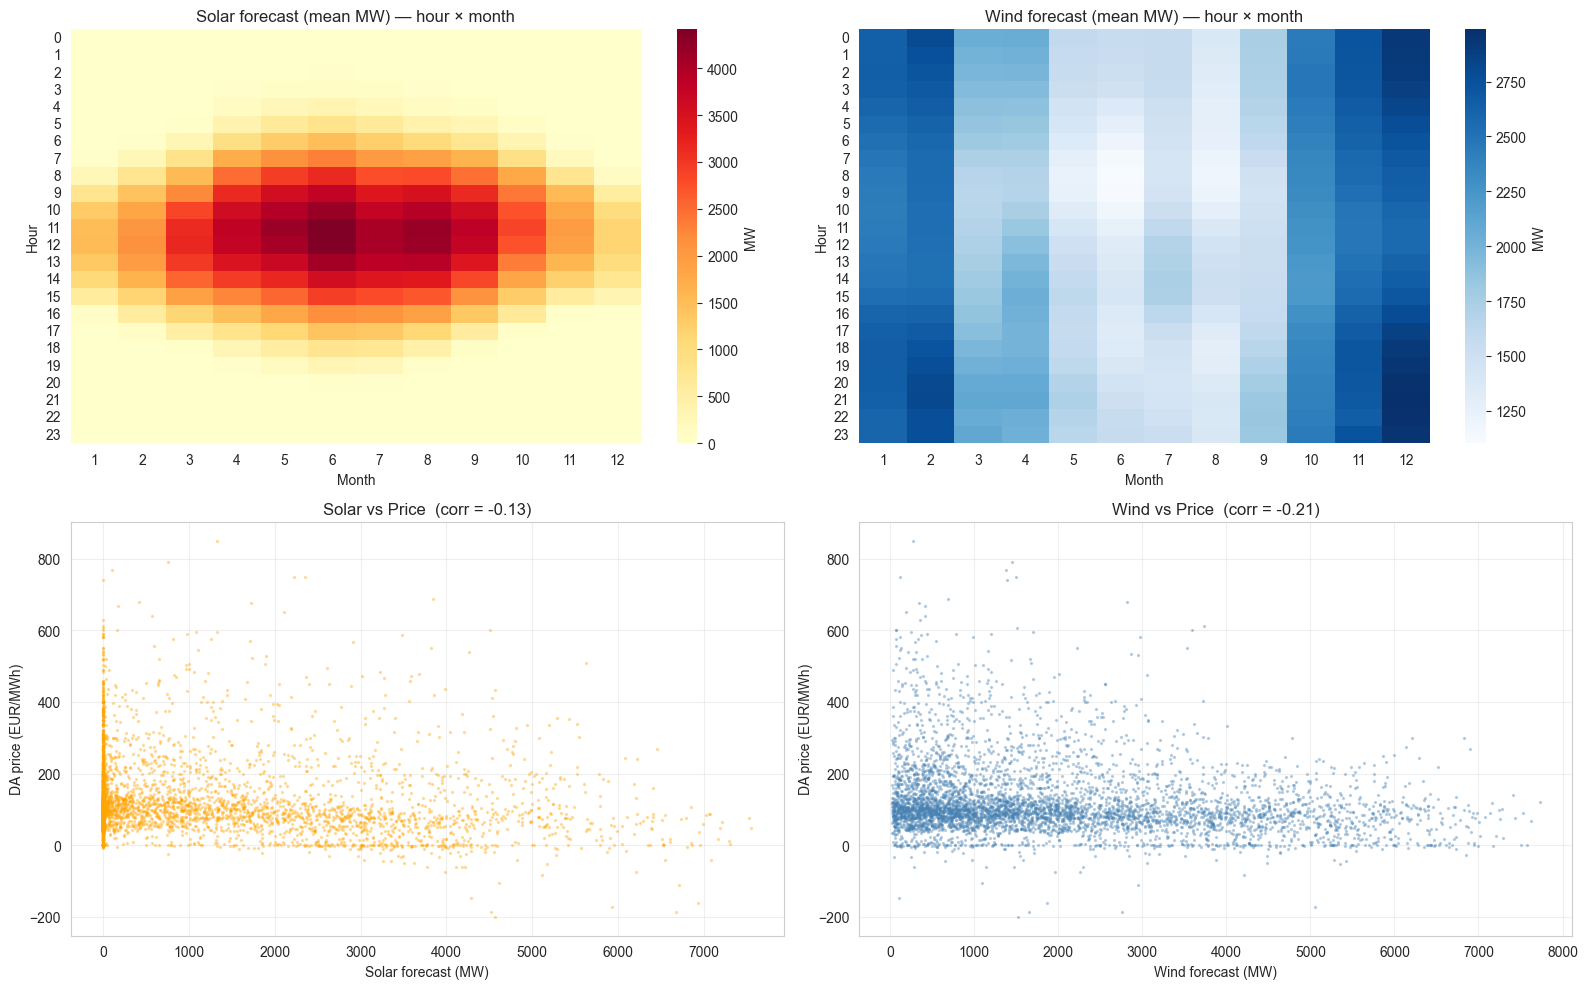

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Solar generation pattern (hour × month)
solar_pivot = df.pivot_table(values="solar_forecast_mw", index=df.index.hour,
                              columns=df.index.month, aggfunc="mean")
sns.heatmap(solar_pivot, ax=axes[0, 0], cmap="YlOrRd", cbar_kws={"label":"MW"})
axes[0, 0].set_title("Solar forecast (mean MW) — hour × month")
axes[0, 0].set_xlabel("Month"); axes[0, 0].set_ylabel("Hour")

# Wind generation pattern
wind_pivot = df.pivot_table(values="wind_forecast_mw", index=df.index.hour,
                             columns=df.index.month, aggfunc="mean")
sns.heatmap(wind_pivot, ax=axes[0, 1], cmap="Blues", cbar_kws={"label":"MW"})
axes[0, 1].set_title("Wind forecast (mean MW) — hour × month")
axes[0, 1].set_xlabel("Month"); axes[0, 1].set_ylabel("Hour")

# Solar vs Price scatter
sample = df.sample(min(5000, len(df)))
axes[1, 0].scatter(sample["solar_forecast_mw"], sample[tgt], s=2, alpha=0.3, color="orange")
axes[1, 0].set_xlabel("Solar forecast (MW)"); axes[1, 0].set_ylabel("DA price (EUR/MWh)")
axes[1, 0].set_title(f"Solar vs Price  (corr = {df['solar_forecast_mw'].corr(df[tgt]):.2f})")

# Wind vs Price scatter
axes[1, 1].scatter(sample["wind_forecast_mw"], sample[tgt], s=2, alpha=0.3, color="steelblue")
axes[1, 1].set_xlabel("Wind forecast (MW)"); axes[1, 1].set_ylabel("DA price (EUR/MWh)")
axes[1, 1].set_title(f"Wind vs Price  (corr = {df['wind_forecast_mw'].corr(df[tgt]):.2f})")

plt.tight_layout()
plt.savefig("eda_renewables.png", dpi=120, bbox_inches="tight")
plt.show()

Heatmaps показывают выраженную сезонность возобновляемой генерации:

* solar generation максимальна днём и летом
* wind generation выше осенью и зимой

Scatter plots показывают отрицательную связь между возобновляемой генерацией и ценой электроэнергии:

* solar vs price: corr ≈ −0.13;
* wind vs price: corr ≈ −0.21.

При росте solar/wind генерации цены в среднем снижаются, а вероятность высоких ценовых spikes уменьшается.

Особенно заметно влияние solar генерации в дневные часы, когда высокая генерация может приводить к очень низким или даже отрицательным ценам. 

In [15]:
# Negative prices vs solar
df_neg = df[df[tgt] < 0]
df_pos = df[df[tgt] >= 0]

print(f"Анализ negative prices")
print(f"Negative price hours: {len(df_neg)} ({len(df_neg)/len(df)*100:.1f}%)")
print(f"\n              Negative   Non-neg")
print(f"Solar forecast: {df_neg['solar_forecast_mw'].mean():>8.0f}  {df_pos['solar_forecast_mw'].mean():>8.0f} MW")
print(f"Wind forecast:  {df_neg['wind_forecast_mw'].mean():>8.0f}  {df_pos['wind_forecast_mw'].mean():>8.0f} MW")
print(f"Load forecast:  {df_neg['load_forecast'].mean():>8.0f}  {df_pos['load_forecast'].mean():>8.0f} MW")
print(f"\nINSIGHT: negative prices coincide with high solar+wind, low load")

Анализ negative prices
Negative price hours: 1513 (3.5%)

              Negative   Non-neg
Solar forecast:     3252       941 MW
Wind forecast:      3016      1977 MW
Load forecast:      8206     11481 MW

INSIGHT: negative prices coincide with high solar+wind, low load


### Анализ negative prices

Отрицательные цены наблюдаются в 1513 часах, что составляет около 3.5% всех наблюдений.

Сравнение периодов с negative prices и обычных периодов показывает, что отрицательные цены чаще возникают при:

- высокой solar generation forecast;
- высокой wind generation forecast;
- низком load forecast.

В среднем в часы с отрицательными ценами solar forecast составляет около 3252 MW против 941 MW в обычные часы, wind forecast — 3016 MW против 1977 MW, а load forecast заметно ниже: 8206 MW против 11481 MW.

Это подтверждает, что negative prices чаще возникают в условиях избытка renewable generation при относительно низком спросе. То есть когда энергии много, спроса мало, а рынок делает финансовое сальто назад.

## 7. Cross-border markets (DE, BE, FR)

NL connected to Germany, Belgium, France. Their prices and flows влияют на NL цены.

Что смотрим:
- Сильно ли коррелируют цены?
- Когда возникают spreads (NL ≠ DE) — это congestion
- Flows показывают физический import/export

Correlation matrix DA prices:
                    nl_day_ahead_price  de_day_ahead_price  be_day_ahead_price  fr_day_ahead_price
nl_day_ahead_price               1.000               0.965               0.977               0.911
de_day_ahead_price               0.965               1.000               0.959               0.893
be_day_ahead_price               0.977               0.959               1.000               0.936
fr_day_ahead_price               0.911               0.893               0.936               1.000


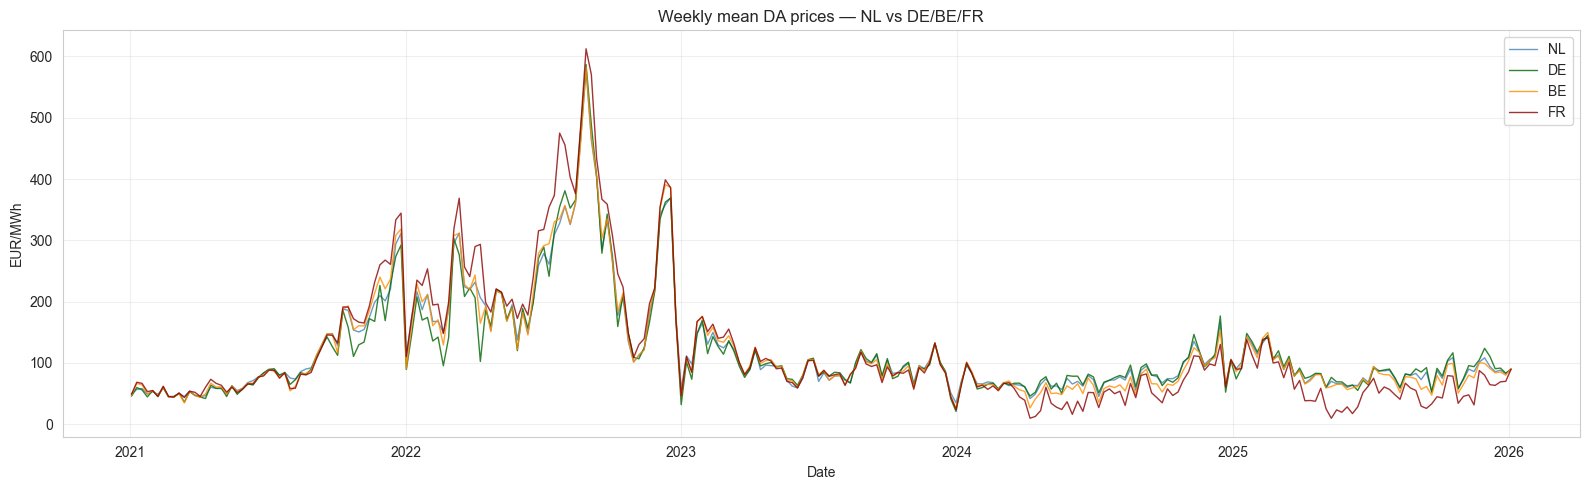

In [18]:
# Корреляция цен между странами
prices = df[["nl_day_ahead_price","de_day_ahead_price","be_day_ahead_price","fr_day_ahead_price"]]
corr_matrix = prices.corr()
print("Correlation matrix DA prices:")
print(corr_matrix.round(3).to_string())

# Time series 4 стран
fig, ax = plt.subplots(figsize=(16, 5))
for col, color in [("nl_day_ahead_price","steelblue"),
                    ("de_day_ahead_price","darkgreen"),
                    ("be_day_ahead_price","darkorange"),
                    ("fr_day_ahead_price","darkred")]:
    ax.plot(df.resample("W").mean()[col].index, df.resample("W").mean()[col].values,
            label=col.split("_")[0].upper(), linewidth=1, alpha=0.8, color=color)
ax.set_ylabel("EUR/MWh"); ax.set_xlabel("Date")
ax.set_title("Weekly mean DA prices — NL vs DE/BE/FR")
ax.legend()
plt.tight_layout()
plt.savefig("eda_cross_border_prices.png", dpi=120, bbox_inches="tight")
plt.show()

Stats spread NL minus DE/BE/FR:
       nl_de_spread  nl_be_spread  nl_fr_spread
count       43820.0       43820.0       43820.0
mean            1.9           1.2           0.8
std            26.4          21.6          48.0
min          -367.0        -483.0       -2733.2
25%            -2.9          -0.3          -2.4
50%             0.0           0.0           0.0
75%             0.1           4.4          12.5
max           332.0         307.5         598.0


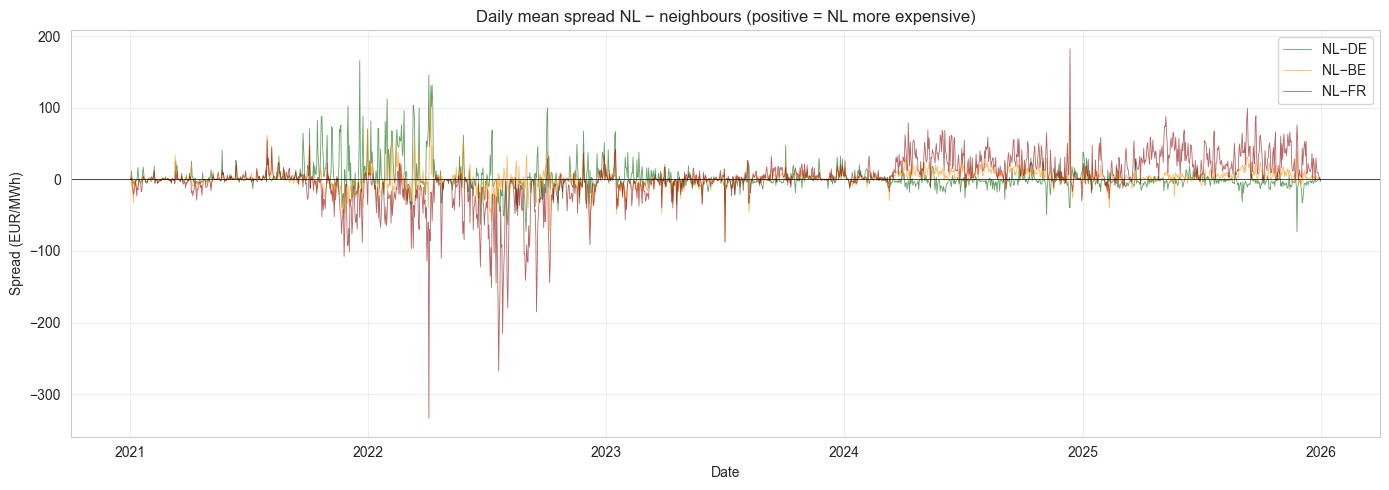

In [19]:
# Spread analysis — когда NL расходится с DE
df_spread = df.copy()
df_spread["nl_de_spread"] = df_spread["nl_day_ahead_price"] - df_spread["de_day_ahead_price"]
df_spread["nl_be_spread"] = df_spread["nl_day_ahead_price"] - df_spread["be_day_ahead_price"]
df_spread["nl_fr_spread"] = df_spread["nl_day_ahead_price"] - df_spread["fr_day_ahead_price"]

print("Stats spread NL minus DE/BE/FR:")
print(df_spread[["nl_de_spread","nl_be_spread","nl_fr_spread"]].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_spread.resample("D").mean()["nl_de_spread"], color="darkgreen", linewidth=0.6, alpha=0.6, label="NL−DE")
ax.plot(df_spread.resample("D").mean()["nl_be_spread"], color="darkorange", linewidth=0.6, alpha=0.6, label="NL−BE")
ax.plot(df_spread.resample("D").mean()["nl_fr_spread"], color="darkred", linewidth=0.6, alpha=0.6, label="NL−FR")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Spread (EUR/MWh)"); ax.set_xlabel("Date")
ax.set_title("Daily mean spread NL − neighbours (positive = NL more expensive)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_spreads.png", dpi=120, bbox_inches="tight")
plt.show()

Цены на электроэнергию в Нидерландах демонстрируют сильную корреляцию с соседними рынками Германии, Бельгии и Франции.

На графике weekly mean prices видно, что:

* основные рыночные движения происходят синхронно
* во всех странах наблюдаются схожие изменения рыночного режима
* особенно заметен общий ценовой пиков в 2022 году во время энергетического кризиса.

При этом spread-анализ показывает, что между рынками сохраняются локальные различия:

* в отдельные периоды NL может быть как дороже, так и дешевле соседних стран
* наиболее волатильные spreads наблюдаются в кризисные периоды
* spread относительно Франции демонстрирует наибольшие отклонения

Это подтверждает, что цены соседних рынков являются важными внешними признаками для forecasting-моделей, поскольку рынок электроэнергии Нидерландов тесно интегрирован с европейской энергосистемой.

## 8. Газ (TTF) и цены на электроэнергию

Электричество частично производится из газа. Поэтому **цена газа = драйвер маржинальной электростанции**.

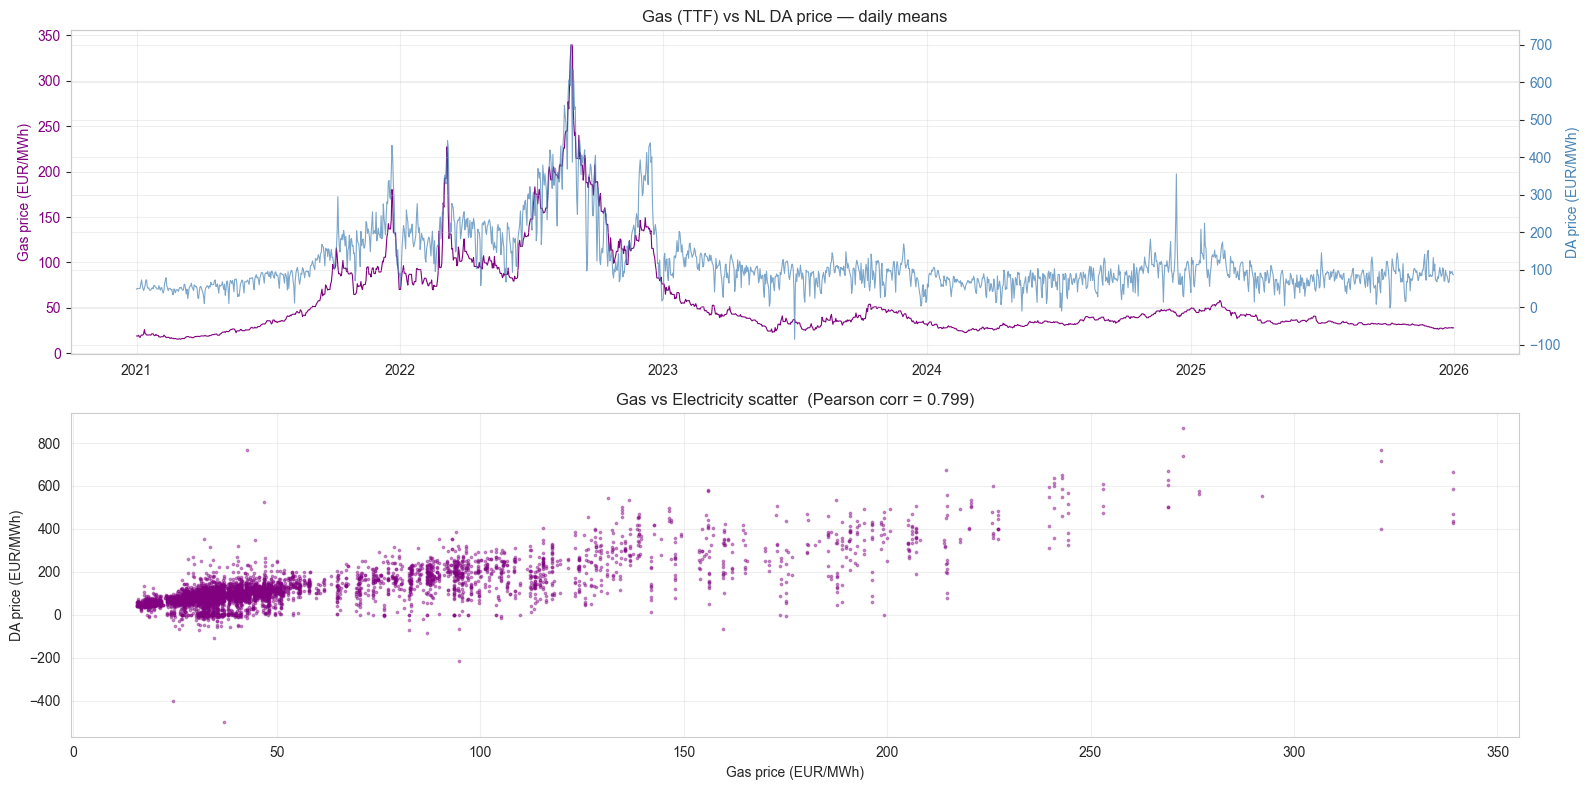


Gas-Electricity correlation by year:
  2021: 0.851
  2022: 0.682
  2023: 0.310
  2024: 0.301
  2025: 0.252


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Time series — gas price
df_d = df.resample("D").mean()
ax1 = axes[0]
ax1.plot(df_d.index, df_d["gas_price"], color="purple", linewidth=0.8, label="Gas (TTF)")
ax1.set_ylabel("Gas price (EUR/MWh)", color="purple")
ax1.tick_params(axis="y", labelcolor="purple")

ax2 = ax1.twinx()
ax2.plot(df_d.index, df_d[tgt], color="steelblue", linewidth=0.8, label="DA price NL", alpha=0.7)
ax2.set_ylabel("DA price (EUR/MWh)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax1.set_title("Gas (TTF) vs NL DA price — daily means")

# Scatter
sample = df.sample(min(5000, len(df)))
axes[1].scatter(sample["gas_price"], sample[tgt], s=3, alpha=0.4, color="purple")
axes[1].set_xlabel("Gas price (EUR/MWh)"); axes[1].set_ylabel("DA price (EUR/MWh)")
corr = df["gas_price"].corr(df[tgt])
axes[1].set_title(f"Gas vs Electricity scatter  (Pearson corr = {corr:.3f})")

plt.tight_layout()
plt.savefig("eda_gas.png", dpi=120, bbox_inches="tight")
plt.show()

# Корреляция по годам
print("\nGas-Electricity correlation by year:")
for yr in range(2021, 2026):
    sub = df[df.index.year == yr]
    if len(sub) > 100:
        c = sub["gas_price"].corr(sub[tgt])
        print(f"  {yr}: {c:.3f}")

Газ остаётся одним из ключевых факторов формирования цен на электроэнергию в Европе.

На графике видно, что динамика цен на газ и NL day-ahead цены во многом движется синхронно, особенно в период энергетического кризиса 2021–2022 годов. Оба рынка демонстрируют резкий рост цен и повышенную волатильность в этот период.

Scatter plot показывает сильную положительную зависимость между ценой газа и ценой электроэнергии:

общий Pearson correlation ≈ 0.80.

Однако корреляция существенно меняется по годам. Это говорит о том, что влияние газа было особенно сильным во время энергетического кризиса, но постепенно ослабло после стабилизации рынка и роста доли возобновляемой энергии.

Тем не менее цена на газ остаётся важным внешним фактором для моделей прогнозирования, поскольку газовые электростанции продолжают играть значимую роль в балансировке энергосистемы. Несмотря на развитие возобновляемой энергетики, в периоды нестабильности рынок электроэнергии всё ещё существенно зависит от динамики газового рынка.

## 9. Корреляции с фичами

Какие переменные сильнее всего связаны с DA ценой?
- Это **подсказывает feature engineering** — что брать в модель
- Pearson — линейная связь
- Spearman — монотонная (rank-based)

Top 20 features by abs(Pearson correlation):
                 feature   pearson  spearman    abs_p
      be_day_ahead_price  0.976685  0.959833 0.976685
      de_day_ahead_price  0.965143  0.941949 0.965143
      fr_day_ahead_price  0.910707  0.876993 0.910707
               gas_price  0.799425  0.689438 0.799425
    imbalance_price_long  0.597352  0.668356 0.597352
   imbalance_price_short  0.567146  0.647984 0.567146
                 wind_ms -0.260375 -0.306673 0.260375
     wind_gusts_forecast -0.251662 -0.305584 0.251662
                 wind_mw -0.235641 -0.245293 0.235641
     wind_speed_forecast -0.234025 -0.270413 0.234025
           load_forecast  0.232442  0.290588 0.232442
        wind_forecast_mw -0.208916 -0.203477 0.208916
         solar_radiation -0.176984 -0.134352 0.176984
solar_radiation_forecast -0.168510 -0.125686 0.168510
                solar_mw -0.162024 -0.142831 0.162024
       pressure_forecast  0.140823  0.181812 0.140823
       solar_forecast_mw -0.130361 -0

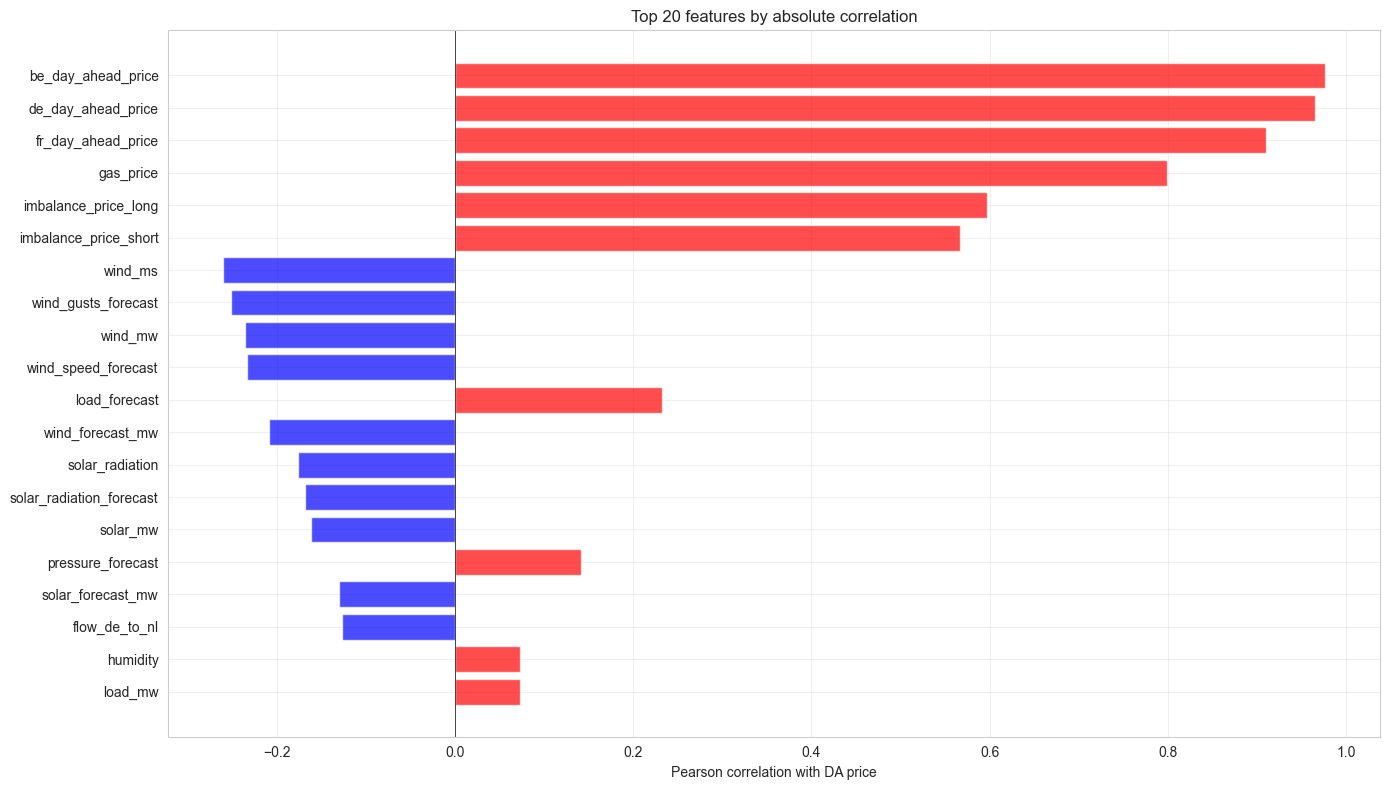

In [21]:
# Корреляция со всеми числовыми фичами
candidates = [c for c in df.columns if c != tgt and df[c].dtype in [np.float64, np.int64]]
corr_data = []
for col in candidates:
    pearson  = df[col].corr(df[tgt])
    spearman = df[col].corr(df[tgt], method="spearman")
    corr_data.append({"feature": col, "pearson": pearson, "spearman": spearman, "abs_p": abs(pearson)})

corr_df = pd.DataFrame(corr_data).sort_values("abs_p", ascending=False)
print("Top 20 features by abs(Pearson correlation):")
print(corr_df.head(20).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(14, 8))
top = corr_df.head(20).iloc[::-1]
ax.barh(top["feature"], top["pearson"], color=["red" if x > 0 else "blue" for x in top["pearson"]], alpha=0.7)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Pearson correlation with DA price")
ax.set_title("Top 20 features by absolute correlation")
plt.tight_layout()
plt.savefig("eda_correlations.png", dpi=120, bbox_inches="tight")
plt.show()

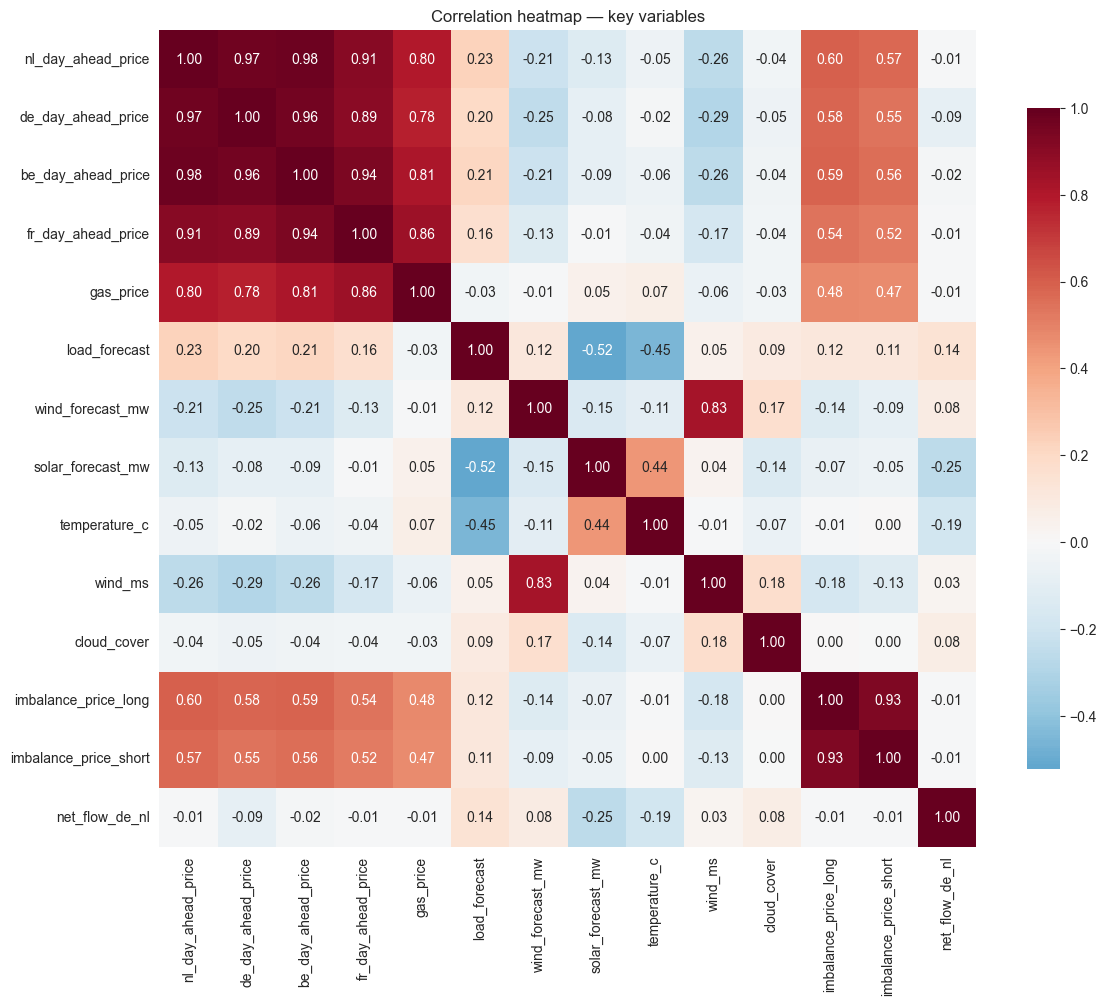

In [22]:
# Heatmap корреляций между ключевыми фичами
key_cols = [tgt, "de_day_ahead_price","be_day_ahead_price","fr_day_ahead_price",
            "gas_price","load_forecast","wind_forecast_mw","solar_forecast_mw",
            "temperature_c","wind_ms","cloud_cover",
            "imbalance_price_long","imbalance_price_short","net_flow_de_nl"]
key_cols = [c for c in key_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[key_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink":0.8}, ax=ax)
ax.set_title("Correlation heatmap — key variables")
plt.tight_layout()
plt.savefig("eda_corr_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

Корреляционный анализ показывает, что наиболее сильную связь с `nl_day_ahead_price` имеют цены соседних рынков:

* `be_day_ahead_price`
* `de_day_ahead_price`
* `fr_day_ahead_price`

Коэффициенты корреляции превышают 0.9, что подтверждает высокую интеграцию европейских рынков электроэнергии.

Сильная положительная связь также наблюдается для:

* `gas_price`
* `imbalance_price_long`
* `imbalance_price_short`

При этом renewable-related признаков демонстрируют отрицательную корреляцию с ценой:

* рост `wind_forecast_mw` и `wind_mw `связан со снижением цены
* аналогичный, но более слабый эффект наблюдается для `solar_forecast_mw` и `solar_mw`

Heatmap дополнительно показывает взаимосвязи между самими признаками:

* высокая корреляция между ценами соседних рынков
* сильная связь между wind forecast и фактической wind generation
* высокая корреляция между imbalance-признаками

При этом важно учитывать, что корреляция отражает только линейную зависимость. Реальный рынок электроэнергии содержит большое количество нелинейных эффектов и feature interactions, которые особенно заметны во время ценовых пиков и смены рыночных режимов.

## 10. Автокорреляция целевой переменной

В этом разделе анализируется временная зависимость `nl_day_ahead_price`:

- насколько текущая цена связана с предыдущими значениями
- сохраняются ли суточные и недельные паттерны
- насколько информативны прошлые значения цены для прогнозирования будущих

Основная цель анализа — проверить наличие временной памяти ряда и обосновать использование lag-признаков при построении forecasting-моделей.

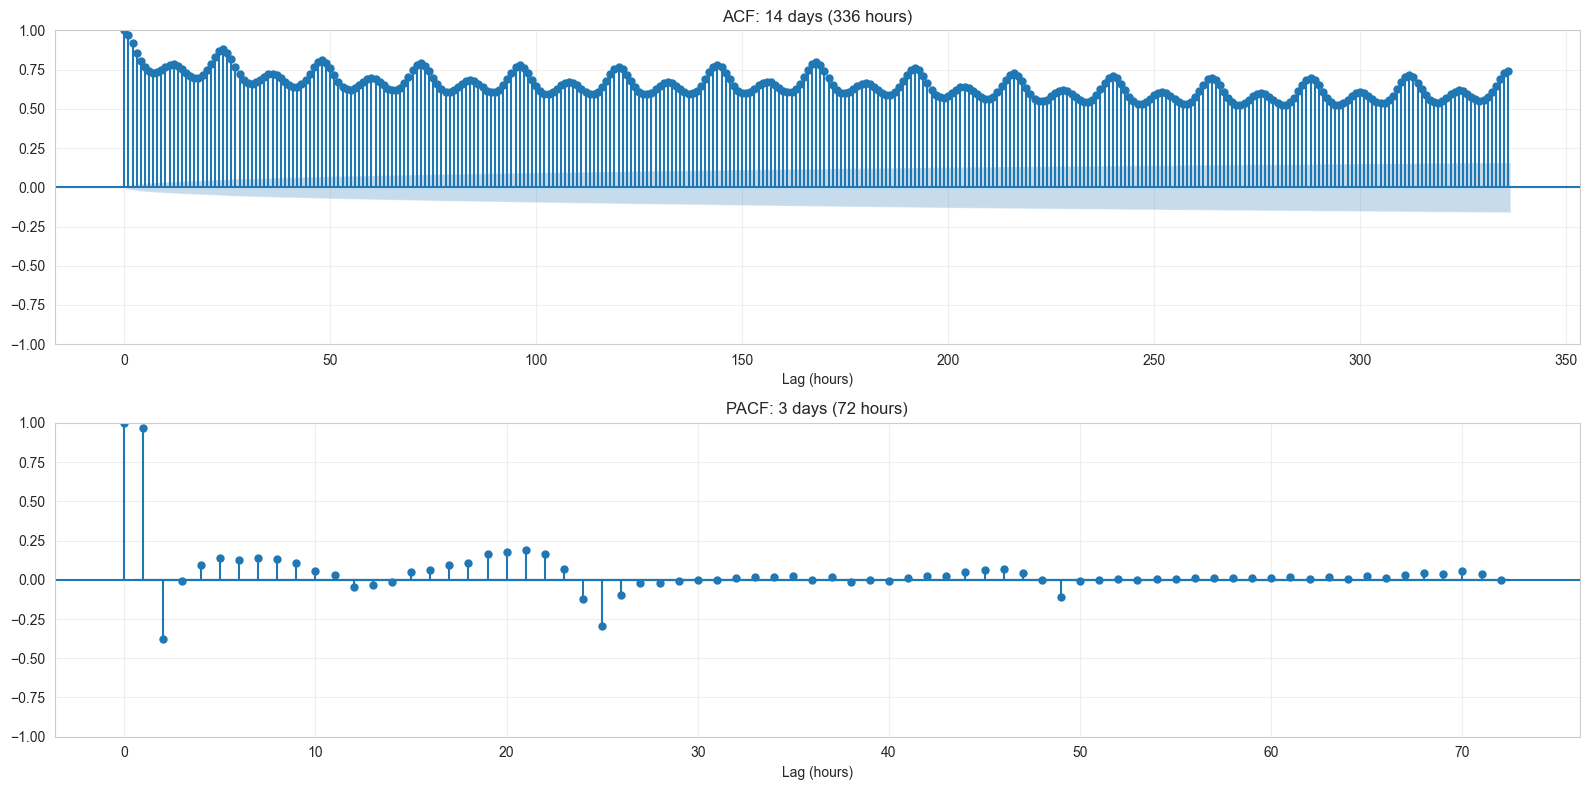

Correlation цены сейчас vs тот же час N дней назад:
  lag  1d ( 24h): 0.879
  lag  2d ( 48h): 0.811
  lag  7d (168h): 0.798
  lag 14d (336h): 0.741
  lag 21d (504h): 0.680
  lag 28d (672h): 0.642


In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF — какие лаги важны
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plot_acf(y.dropna(), lags=24*14, ax=axes[0])
axes[0].set_title("ACF: 14 days (336 hours)")
axes[0].set_xlabel("Lag (hours)")

plot_pacf(y.dropna(), lags=72, ax=axes[1])
axes[1].set_title("PACF: 3 days (72 hours)")
axes[1].set_xlabel("Lag (hours)")

plt.tight_layout()
plt.savefig("eda_acf_pacf.png", dpi=120, bbox_inches="tight")
plt.show()

# Same-hour correlations (lag = N×24)
print("Correlation цены сейчас vs тот же час N дней назад:")
for d in [1, 2, 7, 14, 21, 28]:
    c = y.corr(y.shift(d * 24))
    print(f"  lag {d:2d}d ({d*24:>3d}h): {c:.3f}")

ACF показывает сильную временную зависимость `nl_day_ahead_price`: даже через несколько дней значения цены остаются заметно связаны с прошлыми наблюдениями.

Особенно выражены суточные и недельные паттерны:

* lag 1 день: корреляция 0.879
* lag 2 дня: корреляция 0.811
* lag 7 дней: корреляция 0.798
* lag 14 дней: корреляция 0.741

PACF показывает, что наиболее сильная прямая зависимость наблюдается на ближайших лагах, особенно в первые часы. Также видны повторяющиеся пики около суточного цикла.

Это подтверждает, что прошлые значения цены содержат важную информацию для прогноза. Поэтому в моделях необходимо использовать lag-признаки: 1 день, 2 дня, 7 дней, 14 дней, 21 день и 28 дней.

Выводы по анализу:

Проведённый разведочный анализ показал, что `nl_day_ahead_price` имеет сложную и нестабильную структуру. Распределение цены асимметрично вправо, содержит тяжёлые хвосты, отрицательные значения и частые ценовые спайки. Это означает, что модель должна уметь прогнозировать не только средний уровень цены, но и редкие экстремальные события.

Во временной динамике заметны выраженные сезонные паттерны: годовые изменения рыночного режима, месячная сезонность, различия между рабочими днями и выходными, а также сильная внутрисуточная структура. Особенно важны утренние и вечерние часы пик, где цены и волатильность обычно выше.

Анализ спайков показал, что экстремальные цены возникают не случайно. Высокие спайки чаще наблюдаются в будние дни в часы повышенного спроса, а низкие и отрицательные цены чаще возникают в выходные днём при высокой солнечной и ветровой генерации и низком спросе.

Также выявлена сильная связь цены NL с соседними рынками DE, BE и FR, а также с ценой газа. Это подтверждает важность внешних рыночных факторов. Возобновляемая генерация, наоборот, в среднем снижает цену, особенно при высокой solar/wind generation.

Автокорреляционный анализ показал сильную временную память ряда: цена хорошо связана с предыдущими значениями за 1, 2, 7, 14 и более дней. Поэтому lag-признаки и rolling statistics должны быть важной частью feature engineering.